In [11]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
df=pd.read_csv("Dataset.csv");

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [8]:
rows,column=df.shape

In [10]:
print("Number of rows",rows)

Number of rows 9551


In [11]:
print("Number of columns",column)

Number of columns 21


In [16]:
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [18]:
num_cols=df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols]=df[num_cols].fillna(df[num_cols].mean())

In [19]:
cat_cols=df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [21]:
print("\n Missing values after handling")
print(df.isnull().sum())


 Missing values after handling
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [3]:
df["Aggregate rating"] = pd.to_numeric(df["Aggregate rating"], errors='coerce')

In [4]:
df["Aggregate rating"].dtype

dtype('float64')

In [5]:
df["Aggregate rating"].isnull().sum()

0

In [6]:
df["Aggregate rating"].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

In [7]:
df["Aggregate rating"].value_counts().sort_index()

0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: Aggregate rating, dtype: int64

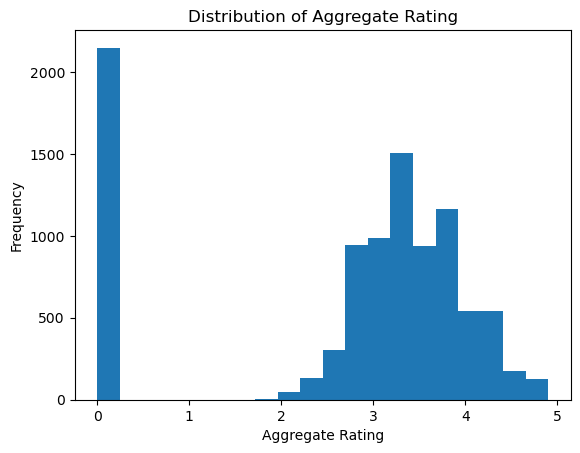

In [12]:
plt.hist(df["Aggregate rating"], bins=20)
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Aggregate Rating")
plt.show()

In [13]:
rating_percentage = df["Aggregate rating"].value_counts(normalize=True) * 100
rating_percentage.sort_index()

0.0    22.489792
1.8     0.010470
1.9     0.020940
2.0     0.073291
2.1     0.157052
2.2     0.282693
2.3     0.492095
2.4     0.910899
2.5     1.151712
2.6     1.999791
2.7     2.617527
2.8     3.298084
2.9     3.989111
3.0     4.900010
3.1     5.433986
3.2     5.465396
3.3     5.057062
3.4     5.214114
3.5     5.025652
3.6     4.795309
3.7     4.470736
3.8     4.188043
3.9     3.507486
4.0     2.785049
4.1     2.868810
4.2     2.313894
4.3     1.821799
4.4     1.507696
4.5     0.994660
4.6     0.816668
4.7     0.439745
4.8     0.261753
4.9     0.638677
Name: Aggregate rating, dtype: float64